In [2]:
"""
Interactive patch labelling notebook.
Displays Sentinel-2 patches and allows manual classification into clearing types.
"""

import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, clear_output
import ipywidgets as widgets

# Load labelling subset
subset_df = pd.read_csv('../data/training/labelling_subset.csv')
patch_dir = Path('../data/training/patches')

# Initialize labels dataframe (or load existing)
labels_file = Path('../data/training/patch_labels.csv')
if labels_file.exists():
    labels_df = pd.read_csv(labels_file)
    print(f"Loaded existing labels: {len(labels_df)} patches already labelled")
else:
    labels_df = pd.DataFrame(columns=['patch_id', 'year', 'clearing_type', 'confidence'])
    print("Starting fresh labelling session")

# Clearing types
CLEARING_TYPES = ['clearcut', 'selective_logging', 'fire', 'storm_damage', 'uncertain']

print(f"Total patches to label: {len(subset_df)}")
print(f"Already labelled: {len(labels_df)}")
print(f"Remaining: {len(subset_df) - len(labels_df)}")

Starting fresh labelling session
Total patches to label: 596
Already labelled: 0
Remaining: 596


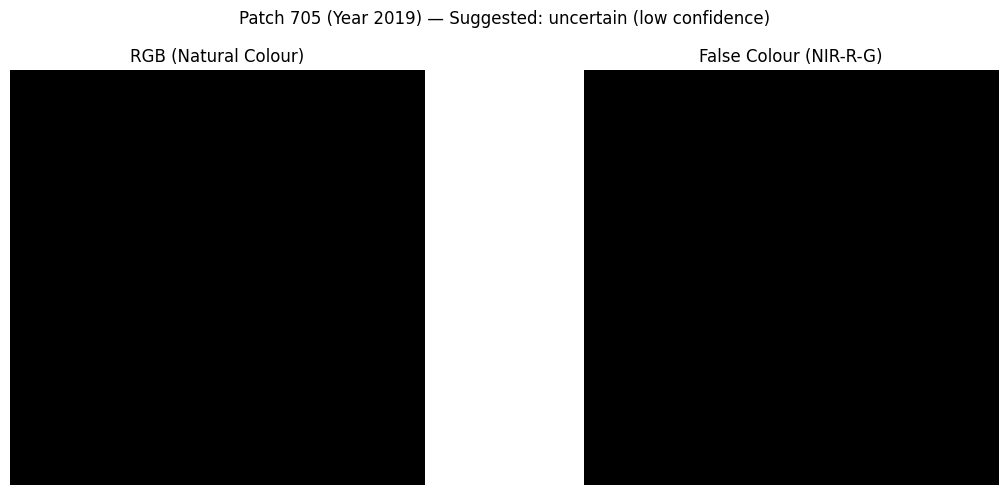

'uncertain'

In [5]:
def calculate_suggested_label(patch_path):
    """
    Calculate NDVI drop and SWIR intensity to suggest a clearing type.
    Returns suggested label and confidence score.
    """
    with rasterio.open(patch_path) as src:
        # Read bands: [B4=Red, B3=Green, B2=Blue, B8=NIR, B11=SWIR]
        bands = src.read()
        
        red = bands[0]
        nir = bands[3]
        swir = bands[4]
        
        # Calculate NDVI (healthy forest = high NDVI, cleared = low NDVI)
        ndvi = (nir - red) / (nir + red + 1e-10)  # add small value to avoid division by zero
        
        # Filter out NaN and zero values before calculating means
        valid_ndvi = ndvi[(~np.isnan(ndvi)) & (ndvi != 0)]
        valid_swir = swir[(~np.isnan(swir)) & (swir != 0)]
        
        # If patch is mostly empty, mark as uncertain
        if len(valid_ndvi) < 100 or len(valid_swir) < 100:
            return 'uncertain', 'low'
        
        mean_ndvi = np.mean(valid_ndvi)
        mean_swir = np.mean(valid_swir)
        
        # Simple heuristic for suggestion
        if mean_swir > 0.3:  # High SWIR suggests fire
            return 'fire', 'medium'
        elif mean_ndvi < 0.2:  # Very low NDVI suggests clearcut
            return 'clearcut', 'medium'
        elif mean_ndvi < 0.4:  # Moderate NDVI suggests selective logging
            return 'selective_logging', 'low'
        else:
            return 'uncertain', 'low'

def display_patch(patch_id, year):
    """Display a patch with RGB and false-colour composites."""
    patch_filename = f"patch_{year}_{patch_id:04d}.tif"
    patch_path = patch_dir / patch_filename
    
    if not patch_path.exists():
        print(f"Patch not found: {patch_filename}")
        return None
    
    with rasterio.open(patch_path) as src:
        # Read bands: [B4=Red, B3=Green, B2=Blue, B8=NIR, B11=SWIR]
        bands = src.read()
        
        def normalize_band(band):
            """Normalize band using 2nd and 98th percentile stretch."""
            valid = band[~np.isnan(band) & (band > 0)]
            if len(valid) < 100:
                return np.zeros_like(band)
            p2, p98 = np.percentile(valid, [2, 98])
            stretched = (band - p2) / (p98 - p2)
            return np.clip(stretched, 0, 1)
        
        # RGB composite (bands 0, 1, 2 = Red, Green, Blue)
        rgb = np.dstack([
            normalize_band(bands[0]),
            normalize_band(bands[1]),
            normalize_band(bands[2])
        ])
        
        # False-colour composite (NIR, Red, Green)
        false_colour = np.dstack([
            normalize_band(bands[3]),
            normalize_band(bands[0]),
            normalize_band(bands[1])
        ])
    
    # Get suggested label
    suggested_label, confidence = calculate_suggested_label(patch_path)
    
    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.imshow(rgb)
    ax1.set_title('RGB (Natural Colour)')
    ax1.axis('off')
    
    ax2.imshow(false_colour)
    ax2.set_title('False Colour (NIR-R-G)')
    ax2.axis('off')
    
    plt.suptitle(f"Patch {patch_id} (Year {year}) — Suggested: {suggested_label} ({confidence} confidence)")
    plt.tight_layout()
    plt.show()
    
    return suggested_label

# Test display on first patch
test_row = subset_df.iloc[0]
display_patch(int(test_row['id']), int(test_row['year']))

In [6]:
# Debug: inspect raw patch values
test_row = subset_df.iloc[0]
patch_filename = f"patch_{int(test_row['year'])}_{int(test_row['id']):04d}.tif"
patch_path = patch_dir / patch_filename

with rasterio.open(patch_path) as src:
    bands = src.read()
    
    print(f"Patch shape: {bands.shape}")
    print(f"Band descriptions: {src.descriptions}")
    print()
    
    for i, name in enumerate(src.descriptions):
        band = bands[i]
        valid = band[~np.isnan(band) & (band > 0)]
        print(f"Band {i} ({name}):")
        print(f"  Valid pixels: {len(valid)} / {band.size}")
        print(f"  Min: {valid.min() if len(valid) > 0 else 'N/A'}")
        print(f"  Max: {valid.max() if len(valid) > 0 else 'N/A'}")
        print(f"  Mean: {valid.mean() if len(valid) > 0 else 'N/A'}")
        print()

Patch shape: (5, 128, 128)
Band descriptions: ('B4', 'B3', 'B2', 'B8', 'B11')

Band 0 (B4):
  Valid pixels: 0 / 16384
  Min: N/A
  Max: N/A
  Mean: N/A

Band 1 (B3):
  Valid pixels: 0 / 16384
  Min: N/A
  Max: N/A
  Mean: N/A

Band 2 (B2):
  Valid pixels: 0 / 16384
  Min: N/A
  Max: N/A
  Mean: N/A

Band 3 (B8):
  Valid pixels: 0 / 16384
  Min: N/A
  Max: N/A
  Mean: N/A

Band 4 (B11):
  Valid pixels: 0 / 16384
  Min: N/A
  Max: N/A
  Mean: N/A



In [8]:
# Check the source mosaic tile
import glob

tiles = sorted(glob.glob('../data/raw/*.tif'))
print(f"Checking first tile: {tiles[0].split('/')[-1]}")

with rasterio.open(tiles[0]) as src:
    bands = src.read()
    
    print(f"Tile shape: {bands.shape}")
    
    for i, name in enumerate(src.descriptions):
        band = bands[i]
        valid = band[~np.isnan(band) & (band != 0)]
        print(f"\nBand {i} ({name}):")
        print(f"  Valid pixels: {len(valid):,} / {band.size:,}")
        if len(valid) > 0:
            print(f"  Min: {valid.min():.4f}")
            print(f"  Max: {valid.max():.4f}")
            print(f"  Mean: {valid.mean():.4f}")

Checking first tile: sentinel2_patches_2019-0000000000-0000000000.tif
Tile shape: (5, 14848, 14848)

Band 0 (B4):
  Valid pixels: 0 / 220,463,104

Band 1 (B3):
  Valid pixels: 0 / 220,463,104

Band 2 (B2):
  Valid pixels: 0 / 220,463,104

Band 3 (B8):
  Valid pixels: 0 / 220,463,104

Band 4 (B11):
  Valid pixels: 0 / 220,463,104
